In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from scipy.stats import ttest_ind, pearsonr

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("✅ Данные загружены")
print(f"Размер данных: {df.shape}")
df.head()

✅ Данные загружены
Размер данных: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Создаём новые признаки
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100],
                         labels=['Young', 'Middle', 'Senior'])
df['smoker_bmi_interaction'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0) * df['bmi']
df['has_children'] = (df['children'] > 0).astype(int)
df['log_charges'] = np.log1p(df['charges'])

print("✅ Новые признаки созданы")
df.head()

✅ Новые признаки созданы


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,smoker_bmi_interaction,has_children,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young,27.9,0,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,Obese,Young,0.0,1,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,Obese,Young,0.0,1,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Middle,0.0,0,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Middle,0.0,0,8.260455


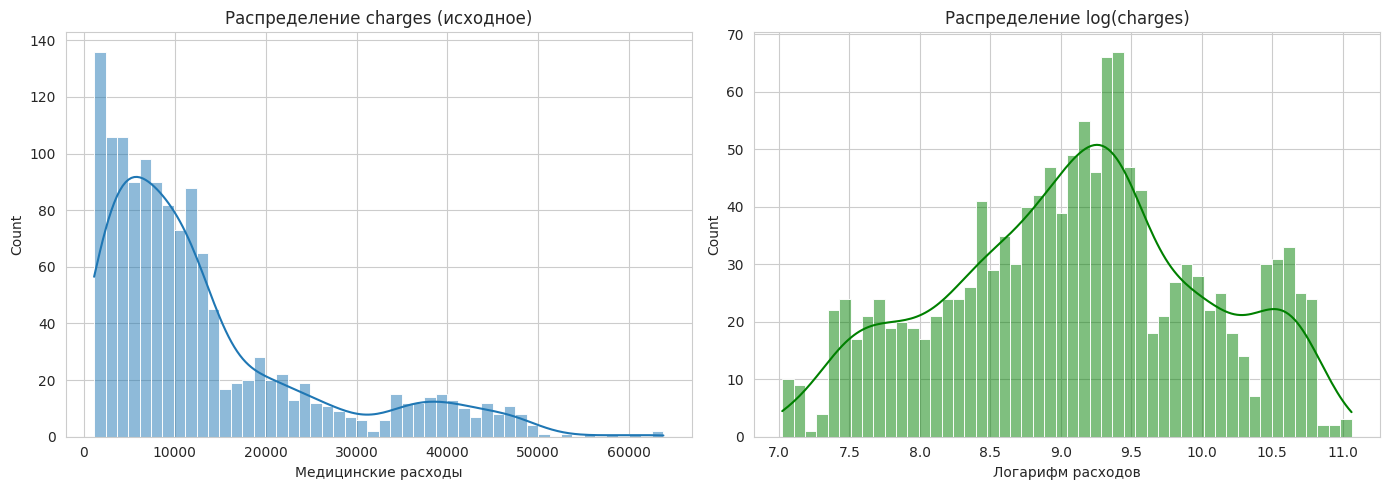

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['charges'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Распределение charges (исходное)')
axes[0].set_xlabel('Медицинские расходы')

sns.histplot(df['log_charges'], bins=50, kde=True, color='green', ax=axes[1])
axes[1].set_title('Распределение log(charges)')
axes[1].set_xlabel('Логарифм расходов')

plt.tight_layout()
plt.savefig('figures/distribution_charges.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6880/3047043884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')


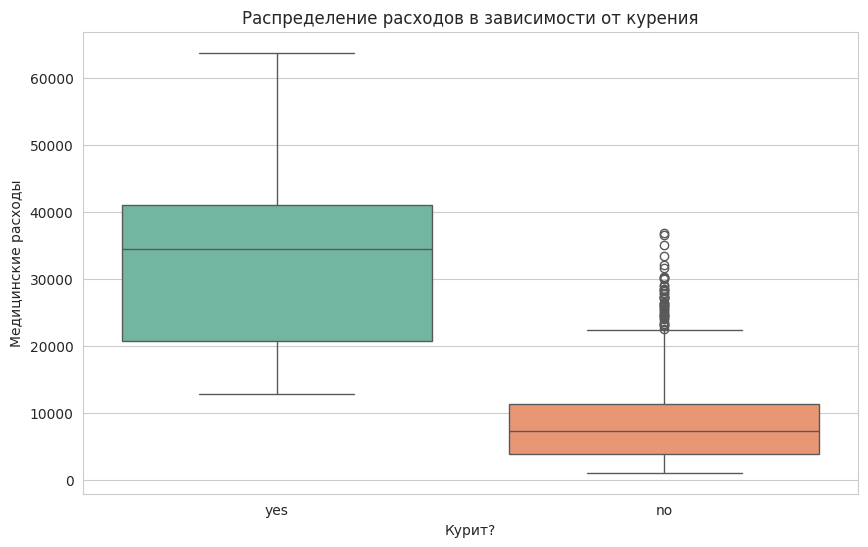

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')
plt.title('Распределение расходов в зависимости от курения')
plt.xlabel('Курит?')
plt.ylabel('Медицинские расходы')
plt.savefig('figures/smoker_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

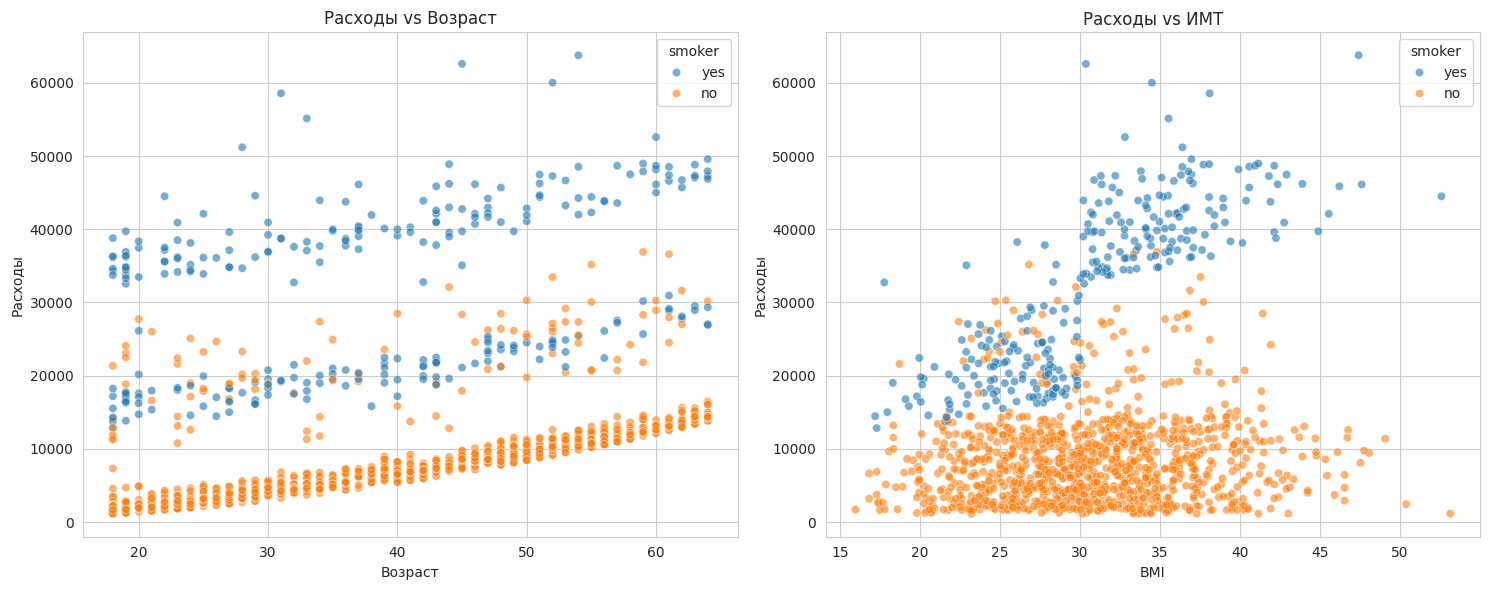

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0])
axes[0].set_title('Расходы vs Возраст')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Расходы')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[1])
axes[1].set_title('Расходы vs ИМТ')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Расходы')

plt.tight_layout()
plt.savefig('figures/age_bmi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

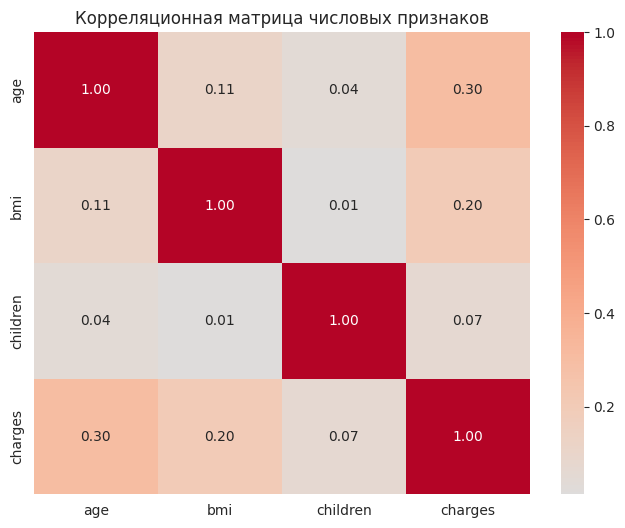

In [22]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6880/1366500774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='charges', errorbar=None, palette='pastel', ax=axes[0])
/tmp/ipykernel_6880/1366500774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='charges', errorbar=None, palette='pastel', ax=axes[1])
/tmp/ipykernel_6880/1366500774.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=df['has_children'].map({0:'Нет детей', 1:'Есть детей'}),


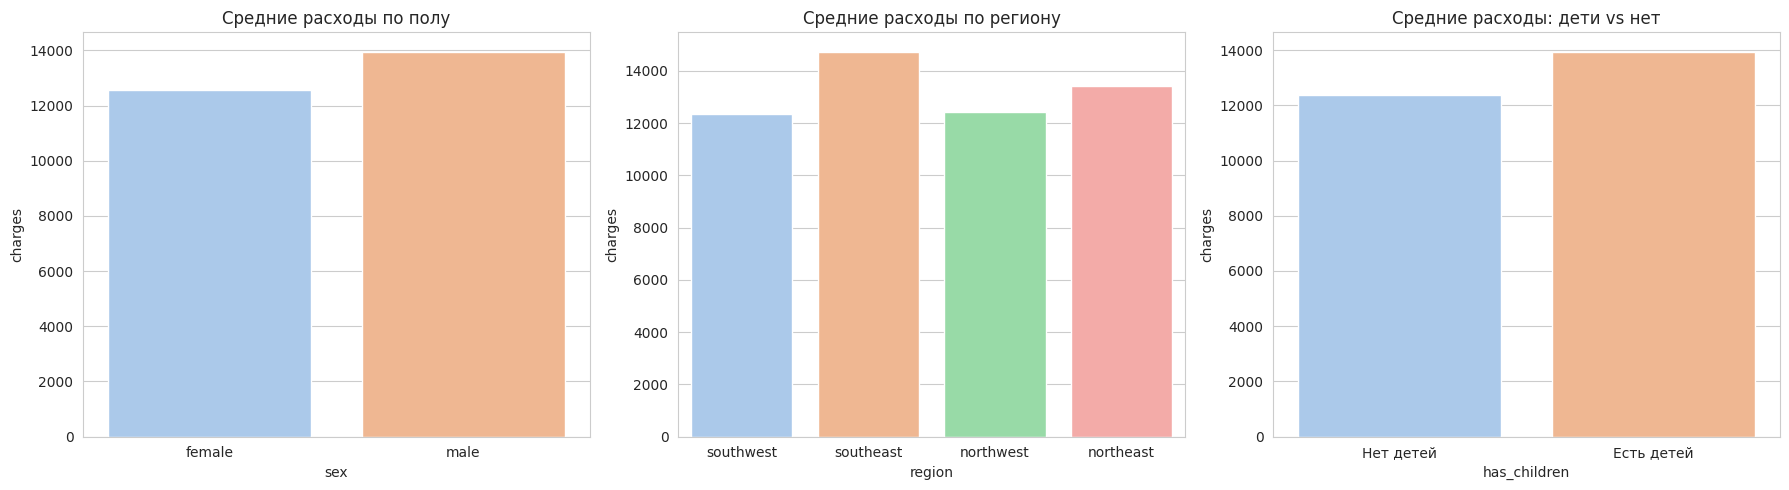

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='sex', y='charges', errorbar=None, palette='pastel', ax=axes[0])
axes[0].set_title('Средние расходы по полу')

sns.barplot(data=df, x='region', y='charges', errorbar=None, palette='pastel', ax=axes[1])
axes[1].set_title('Средние расходы по региону')

sns.barplot(data=df, x=df['has_children'].map({0:'Нет детей', 1:'Есть детей'}),
            y='charges', errorbar=None, palette='pastel', ax=axes[2])
axes[2].set_title('Средние расходы: дети vs нет')

plt.tight_layout()
plt.savefig('figures/category_barplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region',
            'bmi_category', 'age_group', 'smoker_bmi_interaction', 'has_children']
target = 'charges'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (1070, 10)
Тестовая выборка: (268, 10)


In [10]:
categorical_features = ['sex', 'smoker', 'region', 'bmi_category', 'age_group']
numeric_features = ['age', 'bmi', 'children', 'smoker_bmi_interaction', 'has_children']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Pipeline готов")

✅ Pipeline готов


In [11]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    results[name] = scores.mean()
    print(f"{name}: R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

best_model_name = max(results, key=results.get)
print(f"\n🏆 Лучшая модель: {best_model_name}")

LinearRegression: R2 = 0.8354 (+/- 0.0445)
DecisionTree: R2 = 0.6897 (+/- 0.0754)
RandomForest: R2 = 0.8248 (+/- 0.0428)

🏆 Лучшая модель: LinearRegression


In [12]:
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', RandomForestRegressor(random_state=42))])
best_pipeline.fit(X_train, y_train)

y_pred_train = best_pipeline.predict(X_train)
y_pred_test = best_pipeline.predict(X_test)

def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

print_metrics(y_train, y_pred_train, "Train")
print_metrics(y_test, y_pred_test, "Test")

Train: MAE=1073.87, RMSE=1940.50, R2=0.9739
Test: MAE=2550.84, RMSE=4551.47, R2=0.8666


In [13]:
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(best_pipeline, param_grid, cv=5, scoring='r2', verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2 на CV: {grid_search.best_score_:.4f}")

best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test)
print_metrics(y_test, y_pred_tuned, "Test после тюнинга")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучшие параметры: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Лучший R2 на CV: 0.8324
Test после тюнинга: MAE=2526.23, RMSE=4468.22, R2=0.8714


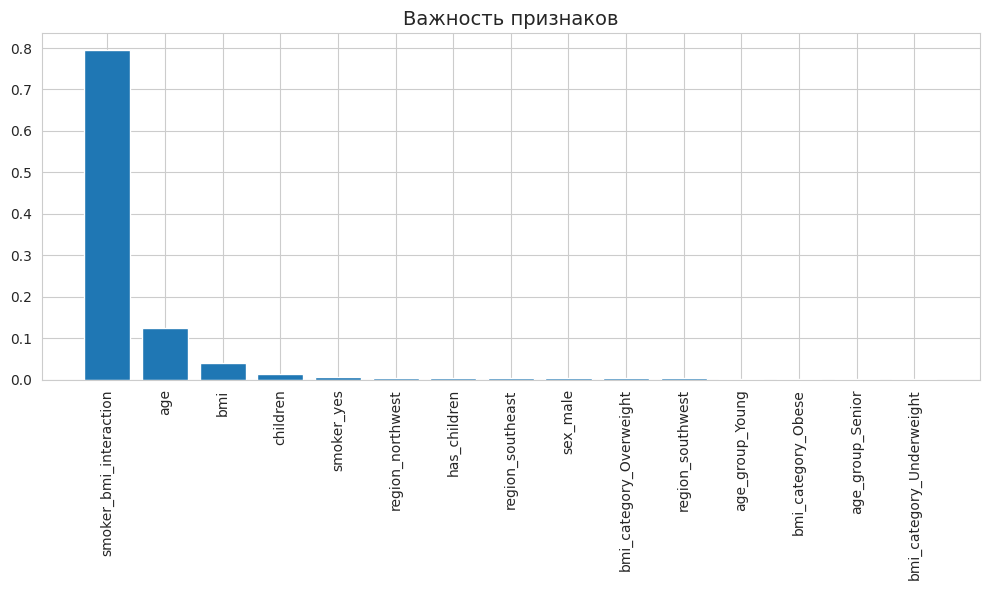

Топ-5 важных признаков:
1. smoker_bmi_interaction: 0.7958
2. age: 0.1241
3. bmi: 0.0402
4. children: 0.0122
5. smoker_yes: 0.0050


In [24]:
rf_model = best_model_tuned.named_steps['regressor']

feature_names = (numeric_features +
                 list(best_model_tuned.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков", fontsize=14)
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Топ-5 важных признаков:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [15]:
# Гипотеза 1: курящие vs некурящие
smoker_yes = df[df['smoker'] == 'yes']['charges']
smoker_no = df[df['smoker'] == 'no']['charges']
t_stat, p_value = ttest_ind(smoker_yes, smoker_no)
print(f"Курящие vs некурящие: p-value = {p_value:.2e}")
print("✅ Гипотеза подтверждена: курящие тратят больше")

# Гипотеза 2: корреляция возраста
corr_age, p_age = pearsonr(df['age'], df['charges'])
print(f"Корреляция возраста и расходов: {corr_age:.3f}, p-value = {p_age:.2e}")
print("✅ С возрастом расходы растут")

# Гипотеза 3: ожирение
obese = df[df['bmi'] > 30]['charges']
non_obese = df[df['bmi'] <= 30]['charges']
t_stat2, p_value2 = ttest_ind(obese, non_obese)
print(f"Ожирение vs норма: p-value = {p_value2:.4f}")
print("✅ Люди с ожирением тратят больше")

Курящие vs некурящие: p-value = 8.27e-283
✅ Гипотеза подтверждена: курящие тратят больше
Корреляция возраста и расходов: 0.299, p-value = 4.89e-29
✅ С возрастом расходы растут
Ожирение vs норма: p-value = 0.0000
✅ Люди с ожирением тратят больше


In [16]:
comparison = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    comparison.append({
        'Model': name,
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'R2': round(r2_score(y_test, y_pred), 4)
    })

comparison_df = pd.DataFrame(comparison).sort_values('R2', ascending=False)
print("Сравнение моделей:")
comparison_df

Сравнение моделей:


,Model,MAE,RMSE,R2
0,LinearRegression,2727.86,4510.31,0.8690
2,RandomForest,2550.84,4551.47,0.8666
1,DecisionTree,2695.57,5732.20,0.7884


In [17]:
import joblib
joblib.dump(best_model_tuned, 'medical_cost_model.pkl')
print("✅ Модель сохранена как medical_cost_model.pkl")

✅ Модель сохранена как medical_cost_model.pkl


In [18]:
!mkdir -p figures
print("Папка 'figures' создана")

Папка 'figures' создана
